In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from data_cleaning import cleaned_data


class Dataset:
    def __init__(self, y_col, y_col_map, other_drop_col, random_state=123):
        self.data = cleaned_data()

        y_df = self.data[y_col].map(y_col_map).to_numpy()
        X_df = pd.get_dummies(
            self.data.drop([y_col, other_drop_col], axis=1),
            drop_first=True
        )

        self.feature_order = X_df.columns
        X_df = X_df.to_numpy()

        self.train_x, self.test_x, self.train_y, self.test_y = train_test_split(
            X_df, y_df, test_size=0.2, random_state=random_state, stratify=y_df
        )


voted_map = {"voted": 1, "not_voted": 0}
dataset_handler = Dataset("VOTED", voted_map, "VOTEHOW")

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    max_features="sqrt",
    oob_score=True,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(dataset_handler.train_x, dataset_handler.train_y)

y_pred = rf.predict(dataset_handler.test_x)
print("Test accuracy:", accuracy_score(dataset_handler.test_y, y_pred))
print("\nClassification report:\n", classification_report(dataset_handler.test_y, y_pred))
print("OOB score:", rf.oob_score_)

importance_df = pd.DataFrame({
    "feature": dataset_handler.feature_order,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 feature importances:")
print(importance_df.head(15))

Test accuracy: 0.7674252068746021

Classification report:
               precision    recall  f1-score   support

           0       0.51      0.18      0.27      2938
           1       0.79      0.95      0.86      9630

    accuracy                           0.77     12568
   macro avg       0.65      0.56      0.57     12568
weighted avg       0.72      0.77      0.72     12568

OOB score: 0.7664412174259001

Top 15 feature importances:
                     feature  importance
1                AGE_elderly    0.163886
14              FAMINC_upper    0.139391
8         EDUC_master_higher    0.135434
13             FAMINC_middle    0.088461
0             AGE_middle_age    0.086452
9      NATIVITY_foreign_born    0.079079
7          EDUC_college_grad    0.076502
2                 SEX_female    0.046429
5                 RACE_asian    0.030236
11              REGION_south    0.030166
12               REGION_west    0.028414
3                 RACE_black    0.027865
10            REGION_m

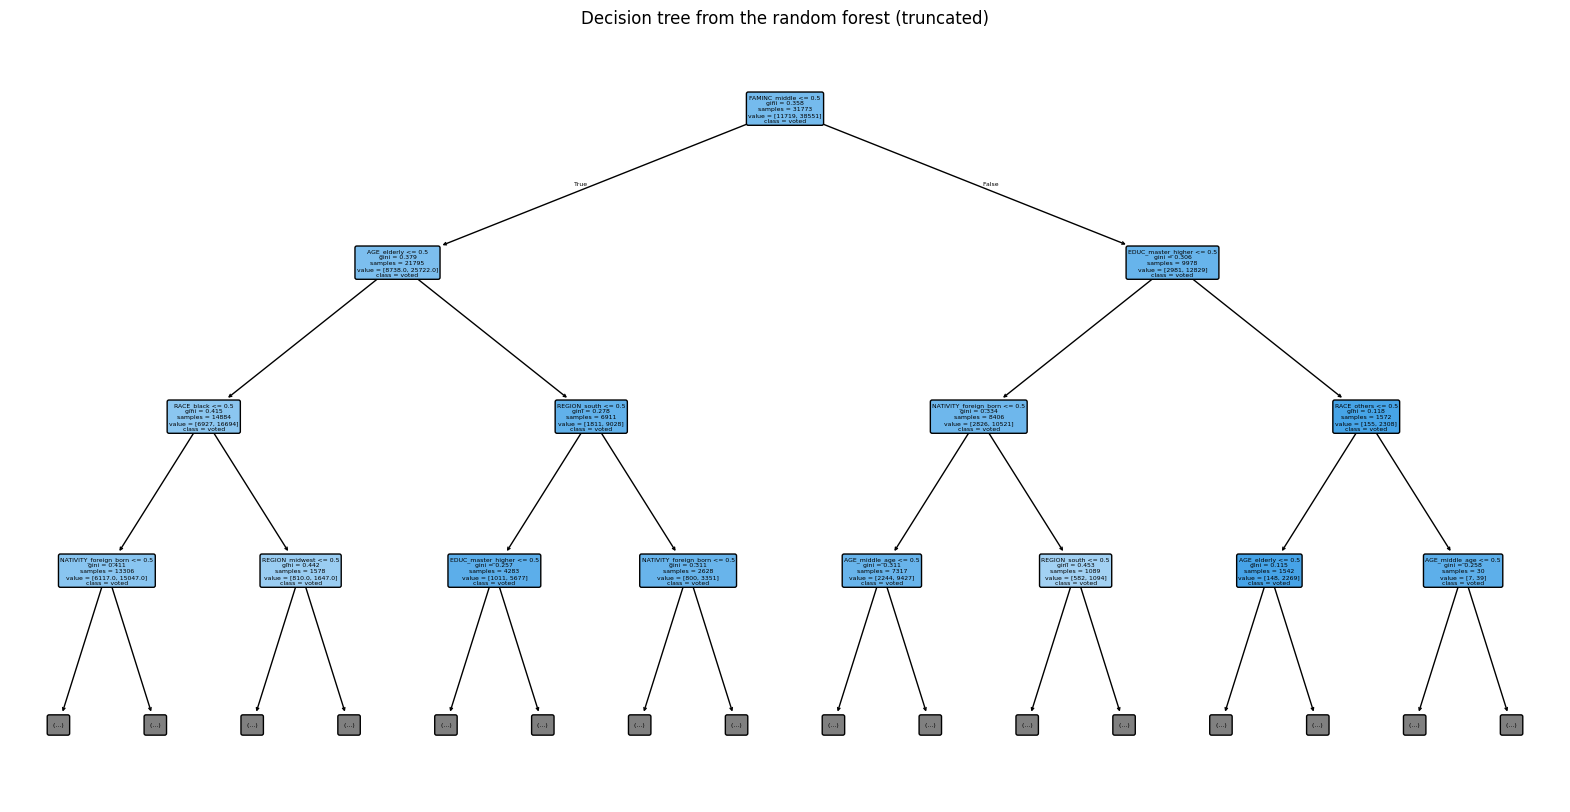

In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Pick one tree from the forest (e.g., the first)
one_tree = rf.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    one_tree,
    feature_names=dataset_handler.feature_order,  # your dummy feature names
    class_names=["not_voted", "voted"],
    filled=True,
    rounded=True,
    max_depth=3  # limit depth so it's readable
)
plt.title("Decision tree from the random forest (truncated)")
plt.show()